In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.figsize'] = (9, 4)

## Load raw data

In [3]:
df = pd.read_csv('../assets/raw/shot_logs.csv')
print('Shape:', df.shape)
df.head()

Shape: (128069, 21)


,GAME_ID,MATCHUP,LOCATION,W,FINAL_MARGIN,SHOT_NUMBER,PERIOD,GAME_CLOCK,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,SHOT_DIST,PTS_TYPE,SHOT_RESULT,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,FGM,PTS,player_name,player_id
0,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,1,1,1:09,10.8,2,1.9,7.7,2,made,"Anderson, Alan",101187,1.3,1,2,brian roberts,203148
1,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,2,1,0:14,3.4,0,0.8,28.2,3,missed,"Bogdanovic, Bojan",202711,6.1,0,0,brian roberts,203148
2,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,3,1,0:00,NaN,3,2.7,10.1,2,missed,"Bogdanovic, Bojan",202711,0.9,0,0,brian roberts,203148
3,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,4,2,11:47,10.3,2,1.9,17.2,2,missed,"Brown, Markel",203900,3.4,0,0,brian roberts,203148
4,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,5,2,10:34,10.9,2,2.7,3.7,2,missed,"Young, Thaddeus",201152,1.1,0,0,brian roberts,203148


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128069 entries, 0 to 128068
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   GAME_ID                     128069 non-null  int64  
 1   MATCHUP                     128069 non-null  str    
 2   LOCATION                    128069 non-null  str    
 3   W                           128069 non-null  str    
 4   FINAL_MARGIN                128069 non-null  int64  
 5   SHOT_NUMBER                 128069 non-null  int64  
 6   PERIOD                      128069 non-null  int64  
 7   GAME_CLOCK                  128069 non-null  str    
 8   SHOT_CLOCK                  122502 non-null  float64
 9   DRIBBLES                    128069 non-null  int64  
 10  TOUCH_TIME                  128069 non-null  float64
 11  SHOT_DIST                   128069 non-null  float64
 12  PTS_TYPE                    128069 non-null  int64  
 13  SHOT_RESULT              

## Missing values

`SHOT_CLOCK` is typically missing when the shot clock is off (late in a period).

In [5]:
nulls = df.isna().sum()
nulls[nulls > 0].to_frame('n_missing').assign(pct=lambda x: (x.n_missing / len(df) * 100).round(2))

,n_missing,pct
SHOT_CLOCK,5567,4.35


In [6]:
# Sanity check: SHOT_CLOCK NaNs should mostly be end-of-period shots.
# GAME_CLOCK is 'MM:SS' — parse briefly just for inspection.
game_seconds = pd.to_timedelta('00:' + df['GAME_CLOCK']).dt.total_seconds()
print('Median GAME_CLOCK when SHOT_CLOCK is NaN:', game_seconds[df['SHOT_CLOCK'].isna()].median(), 'sec')
print('Median GAME_CLOCK overall                :', game_seconds.median(), 'sec')

Median GAME_CLOCK when SHOT_CLOCK is NaN: 6.0 sec
Median GAME_CLOCK overall                : 352.0 sec


## Target variable — `FGM`

1 = made, 0 = missed.

FGM
0    70164
1    57905
Name: count, dtype: int64

Overall FG%: 0.4521


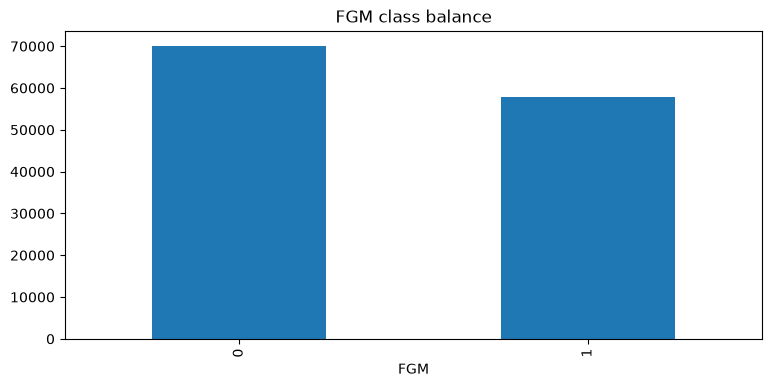

In [8]:
print(df['FGM'].value_counts())
print(f"\nOverall FG%: {df['FGM'].mean():.4f}")
df['FGM'].value_counts().plot.bar(title='FGM class balance');

## Numeric feature distributions

In [9]:
numeric_cols = ['SHOT_NUMBER', 'PERIOD', 'SHOT_CLOCK', 'DRIBBLES',
                'TOUCH_TIME', 'SHOT_DIST', 'CLOSE_DEF_DIST', 'FINAL_MARGIN']
df[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
SHOT_NUMBER,128069.0,6.51,4.71,1.0,3.0,5.0,9.00,38.0
PERIOD,128069.0,2.47,1.14,1.0,1.0,2.0,3.00,7.0
SHOT_CLOCK,122502.0,12.45,5.76,0.0,8.2,12.3,16.68,24.0
DRIBBLES,128069.0,2.02,3.48,0.0,0.0,1.0,2.00,32.0
TOUCH_TIME,128069.0,2.77,3.04,-163.6,0.9,1.6,3.70,24.9
SHOT_DIST,128069.0,13.57,8.89,0.0,4.7,13.7,22.50,47.2
CLOSE_DEF_DIST,128069.0,4.12,2.76,0.0,2.3,3.7,5.30,53.2
FINAL_MARGIN,128069.0,0.21,13.23,-53.0,-8.0,1.0,9.00,53.0


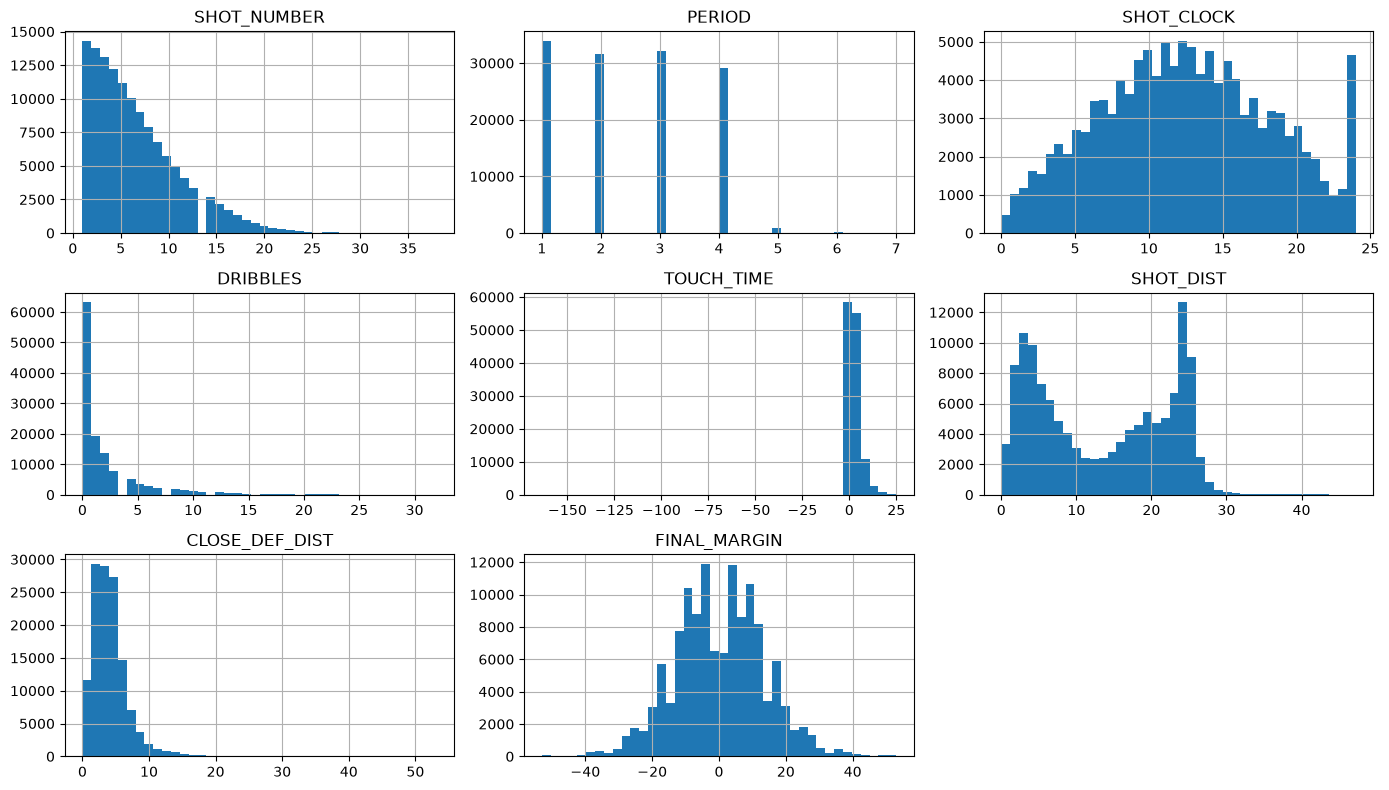

In [10]:
df[numeric_cols].hist(bins=40, figsize=(14, 8))
plt.tight_layout();

## Data quality issues

Look for impossible values that need clipping/fixing during cleaning.

In [11]:
print('TOUCH_TIME < 0        :', (df['TOUCH_TIME'] < 0).sum(),  '  min:', df['TOUCH_TIME'].min())
print('TOUCH_TIME > 24       :', (df['TOUCH_TIME'] > 24).sum(), '  max:', df['TOUCH_TIME'].max())
print('SHOT_DIST < 0         :', (df['SHOT_DIST']  < 0).sum())
print('SHOT_CLOCK > 24       :', (df['SHOT_CLOCK'] > 24).sum())
print('DRIBBLES < 0          :', (df['DRIBBLES']   < 0).sum())
print('CLOSE_DEF_DIST < 0    :', (df['CLOSE_DEF_DIST'] < 0).sum())
print('PERIOD unique values  :', sorted(df['PERIOD'].unique()))

TOUCH_TIME < 0        : 312   min: -163.6
TOUCH_TIME > 24       : 4   max: 24.9
SHOT_DIST < 0         : 0
SHOT_CLOCK > 24       : 0
DRIBBLES < 0          : 0
CLOSE_DEF_DIST < 0    : 0
PERIOD unique values  : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


## Categorical / low-cardinality features

In [12]:
for col in ['LOCATION', 'W', 'PTS_TYPE', 'SHOT_RESULT', 'PERIOD']:
    print(f"{col:15s} -> {df[col].value_counts().to_dict()}")

LOCATION        -> {'A': 64135, 'H': 63934}
W               -> {'W': 64595, 'L': 63474}
PTS_TYPE        -> {2: 94173, 3: 33896}
SHOT_RESULT     -> {'missed': 70164, 'made': 57905}
PERIOD          -> {1: 33961, 3: 32211, 2: 31651, 4: 29123, 5: 912, 6: 168, 7: 43}


## High-cardinality identifiers

Candidates for target encoding or embeddings — too many unique values for one-hot.

In [ ]:
for col in ['GAME_ID', 'MATCHUP', 'player_id', 'CLOSEST_DEFENDER_PLAYER_ID']:
    print(f"{col:30s} unique: {df[col].nunique():>6}   avg rows/id: {len(df)/df[col].nunique():.1f}")

In [13]:
# Most prolific shooters + their FG%
shooter_stats = (df.groupby('player_name')
                   .agg(shots=('FGM','size'), fg_pct=('FGM','mean'))
                   .sort_values('shots', ascending=False))
shooter_stats.head(15)

,shots,fg_pct
player_name,,
james harden,1054,0.449715
mnta ellis,1052,0.449620
lamarcus aldridge,1050,0.450476
damian lillard,986,0.432049
lebron james,978,0.488753
klay thompson,971,0.462410
russell westbrook,969,0.435501
stephen curry,968,0.485537
kyrie irving,942,0.466030


## Feature relates to FG%

Each candidate feature *actually* separate made from missed shots?

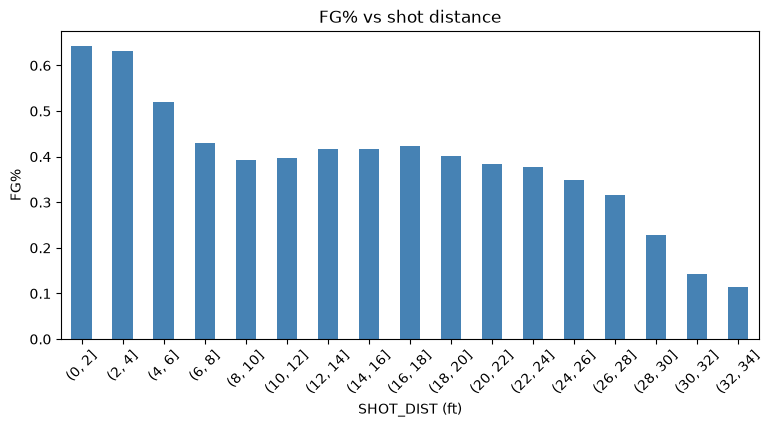

In [14]:
# FG% by shot distance (binned)
bins = np.arange(0, 35, 2)
fg_by_dist = df.groupby(pd.cut(df['SHOT_DIST'], bins))['FGM'].agg(['mean','size'])
fig, ax = plt.subplots()
fg_by_dist['mean'].plot.bar(ax=ax, color='steelblue')
ax.set_ylabel('FG%'); ax.set_xlabel('SHOT_DIST (ft)')
ax.set_title('FG% vs shot distance');
plt.xticks(rotation=45);

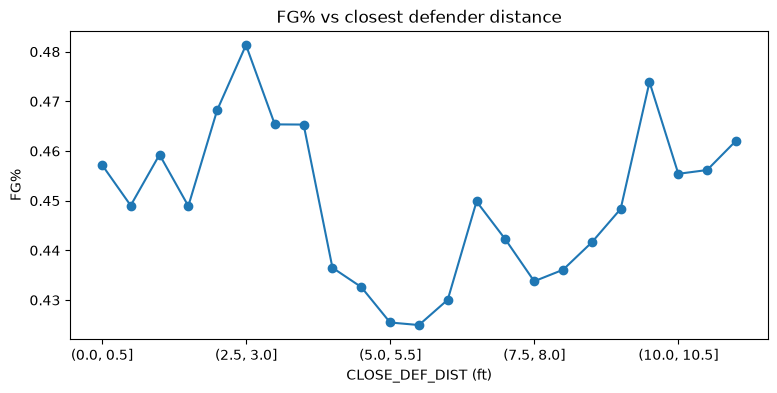

In [15]:
# FG% by closest defender distance
bins = np.arange(0, 12, 0.5)
fg_by_def = df.groupby(pd.cut(df['CLOSE_DEF_DIST'], bins))['FGM'].mean()
fg_by_def.plot(marker='o', title='FG% vs closest defender distance');
plt.ylabel('FG%'); plt.xlabel('CLOSE_DEF_DIST (ft)');

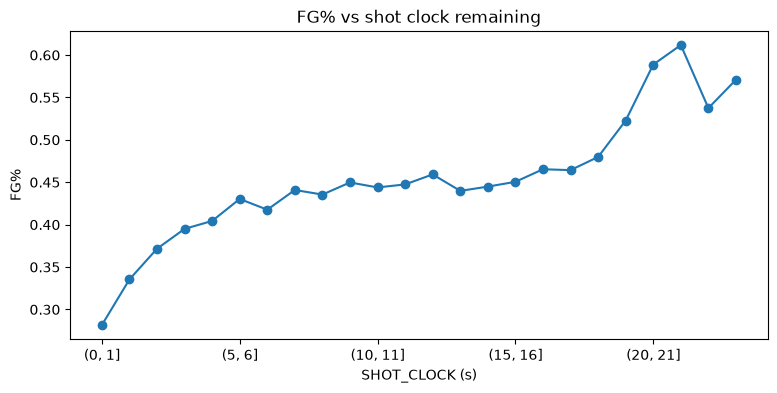

In [16]:
# FG% by shot clock remaining (does late-clock desperation hurt?)
bins = np.arange(0, 25, 1)
fg_by_sc = df.groupby(pd.cut(df['SHOT_CLOCK'], bins))['FGM'].mean()
fg_by_sc.plot(marker='o', title='FG% vs shot clock remaining');
plt.ylabel('FG%'); plt.xlabel('SHOT_CLOCK (s)');

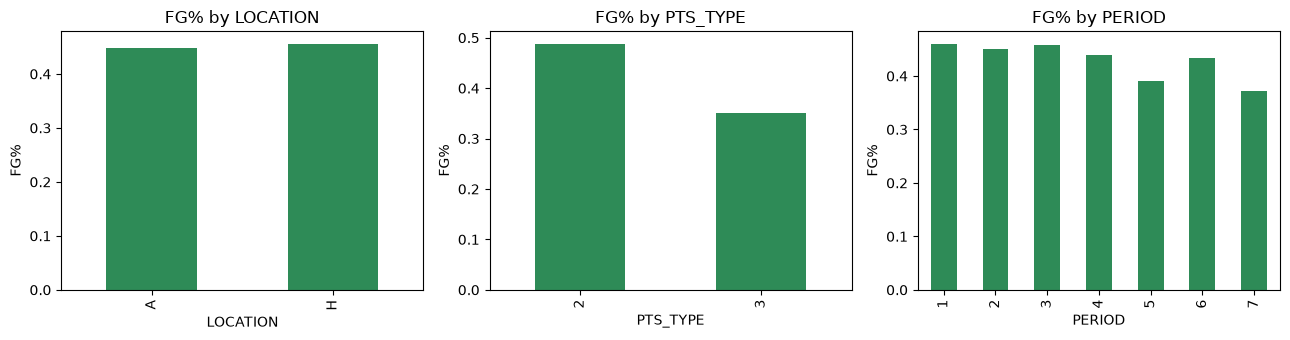

In [17]:
# FG% by small categoricals
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, ['LOCATION', 'PTS_TYPE', 'PERIOD']):
    df.groupby(col)['FGM'].mean().plot.bar(ax=ax, color='seagreen')
    ax.set_title(f'FG% by {col}'); ax.set_ylabel('FG%')
plt.tight_layout();

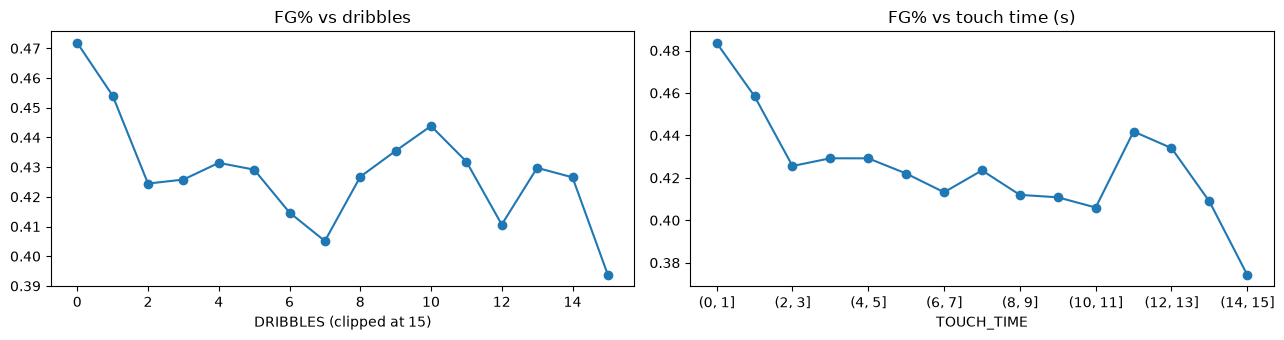

In [18]:
# FG% by DRIBBLES and TOUCH_TIME
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
df.groupby(df['DRIBBLES'].clip(upper=15))['FGM'].mean().plot(marker='o', ax=axes[0])
axes[0].set_title('FG% vs dribbles'); axes[0].set_xlabel('DRIBBLES (clipped at 15)')

tt = df['TOUCH_TIME'].clip(0, 15)
df.groupby(pd.cut(tt, np.arange(0, 16, 1)))['FGM'].mean().plot(marker='o', ax=axes[1])
axes[1].set_title('FG% vs touch time (s)'); axes[1].set_xlabel('TOUCH_TIME')
plt.tight_layout();

## Correlation heatmap

Linear correlations between numeric features. Useful for spotting redundancy.

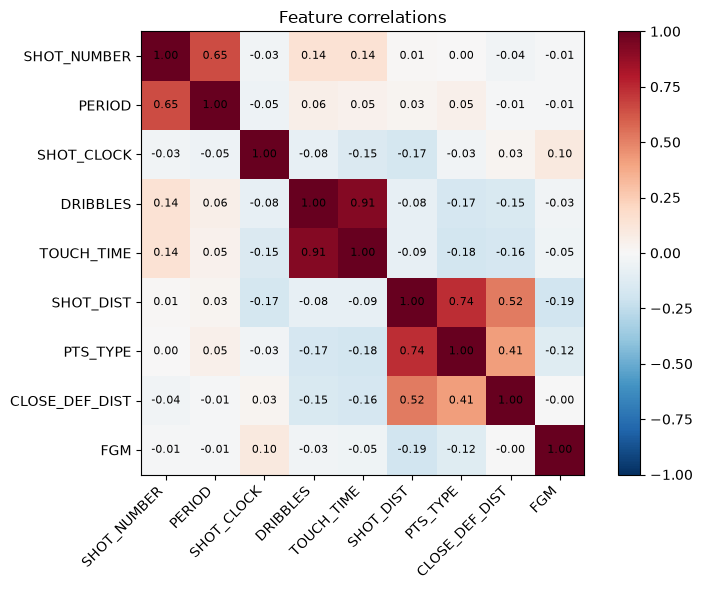

In [19]:
corr_cols = ['SHOT_NUMBER','PERIOD','SHOT_CLOCK','DRIBBLES','TOUCH_TIME',
             'SHOT_DIST','PTS_TYPE','CLOSE_DEF_DIST','FGM']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im); plt.title('Feature correlations'); plt.tight_layout();

In [20]:
# Sorted correlation with the target
corr['FGM'].drop('FGM').sort_values(key=abs, ascending=False).to_frame('corr_with_FGM').round(3)

,corr_with_FGM
SHOT_DIST,-0.192
PTS_TYPE,-0.121
SHOT_CLOCK,0.097
TOUCH_TIME,-0.045
DRIBBLES,-0.034
PERIOD,-0.014
SHOT_NUMBER,-0.008
CLOSE_DEF_DIST,-0.001
